# **🌍 Predicción de Calidad del Aire Urbano**

## **Semana1**

### ***Importaciones***

In [1]:
#!pip install -q \
#tensorflow==2.15.1 \
 # keras==2.15.0 \
  #numpy<2 \
  #typing_extensions>=4.8 \
  #protobuf>=3.20.3,<5 \
  #contourpy>=1.2

In [2]:
# ! pip install python-dotenv

In [3]:
import os
import numpy as np
import tensorflow as tf
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential  # ← CORREGIDO
from tensorflow.keras.layers import LSTM, Dense, Input  # ← CORREGIDO
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

2026-05-03 15:38:24.347157: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 15:38:24.632152: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-03 15:38:24.632329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-03 15:38:24.687398: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-03 15:38:24.800515: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 15:38:24.802255: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [4]:
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("AEMET_API_KEY")

# **APIS**

### ***Definir estaciones***

In [5]:
STATIONS = [
    {"station": "Miranda de Ebro", "latitude": 42.6853, "longitude": -2.9403},
    {"station": "Valladolid", "latitude": 41.6523, "longitude": -4.7245},
    {"station": "Burgos", "latitude": 42.3439, "longitude": -3.6969},
    {"station": "León", "latitude": 42.5987, "longitude": -5.5671},
    {"station": "Salamanca", "latitude": 40.9701, "longitude": -5.6635},
]

Definimos las variables con: ``nombre``, ``latitud``, ``longitud``

### ***API calidad del aire***

In [6]:
def fetch_air_quality(lat, lon, forecast_days=3):
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join([
            "pm10",
            "pm2_5",
            "nitrogen_dioxide",
            "ozone",
            "sulphur_dioxide",
            "carbon_monoxide",
            "european_aqi",
        ]),
        "forecast_days": forecast_days,
        "timezone": "Europe/Madrid",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    return pd.DataFrame(response.json()["hourly"])

Obtenemos la variable objeto + features principales

### ***API meteorológica***

In [7]:
def fetch_weather(lat, lon, forecast_days=3):
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ",".join([
            "temperature_2m",
            "precipitation",
        ]),
        "forecast_days": forecast_days,
        "timezone": "Europe/Madrid",
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    return pd.DataFrame(response.json()["hourly"])


Obtenemos: ``temperatura`` ``precipitación``

### ***Información espacial***

In [8]:
def get_station_data(station):
    lat = station["latitude"]
    lon = station["longitude"]

    air_df = fetch_air_quality(lat, lon)
    weather_df = fetch_weather(lat, lon)

    df = air_df.merge(weather_df, on="time", how="inner")

    df["station"] = station["station"]
    df["latitude"] = lat
    df["longitude"] = lon

    return df

Cada fila sabe: 
- dónde (estación)
- cuándo (time)
- qué valores (contaminantes + clima)

### ***Combinación final***

In [9]:
from pathlib import Path

BASE_DIR = Path.cwd().parent 

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Guardando en:", RAW_DIR)
print("Guardando en:", PROCESSED_DIR)

Guardando en: /workspaces/Air-Quality-AI-Predictor/data/raw
Guardando en: /workspaces/Air-Quality-AI-Predictor/data/processed


In [10]:
import time

In [11]:
def main():
    # Lista para guardar datos
    all_data = []

    # Bucle por estaciones: Recorres todas las ciudades (Valladolid, Burgos, etc.).
    for station in STATIONS:
        print(f"Descargando datos de {station['station']}...")

        try:
            df_station = get_station_data(station)
            all_data.append(df_station)
        except Exception as e:
            print(f"Error con {station['station']}: {e}")

        # Pausa entre llamadas
        time.sleep(1)

    # Unimos todas las ciudades
    df = pd.concat(all_data, ignore_index=True)

    # Convertir tiempo
    df["time"] = pd.to_datetime(df["time"])

    expected_columns = [
        "pm10",
        "pm2_5",
        "nitrogen_dioxide",
        "ozone",
        "sulphur_dioxide",
        "carbon_monoxide",
        "european_aqi",
        "temperature_2m",
        "precipitation",
    ]

    for col in expected_columns:
        if col not in df.columns:
            df[col] = None

    df = df[
        [
            "time",
            "station",
            "latitude",
            "longitude",
            *expected_columns
        ]
    ]

    # Ordenamos datos
    df = df.sort_values(["station", "time"])

    df.to_csv(RAW_DIR / "openmeteo_combined_raw.csv", index=False)
    df.to_csv(PROCESSED_DIR / "air_weather_combined.csv", index=False)

    print("Dataset combinado guardado correctamente.")
    print(df.head())
    print(df.shape)

In [12]:
main()

Descargando datos de Miranda de Ebro...
Descargando datos de Valladolid...
Descargando datos de Burgos...
Descargando datos de León...
Descargando datos de Salamanca...
Dataset combinado guardado correctamente.
                   time station  latitude  longitude  pm10  pm2_5  \
144 2026-05-03 00:00:00  Burgos   42.3439    -3.6969   4.8    3.3   
145 2026-05-03 01:00:00  Burgos   42.3439    -3.6969   5.1    3.3   
146 2026-05-03 02:00:00  Burgos   42.3439    -3.6969   4.5    3.4   
147 2026-05-03 03:00:00  Burgos   42.3439    -3.6969   4.5    3.4   
148 2026-05-03 04:00:00  Burgos   42.3439    -3.6969   4.3    3.5   

     nitrogen_dioxide  ozone  sulphur_dioxide  carbon_monoxide  european_aqi  \
144               3.0   62.0              0.3            112.0            25   
145               3.0   59.0              0.3            111.0            24   
146               3.0   56.0              0.2            108.0            22   
147               3.0   56.0              0.2         

## **Tratamiento de columnas / limpieza + features básicas**

In [13]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

INPUT_PATH = BASE_DIR / "data" / "processed" / "air_weather_combined.csv"
OUTPUT_PATH = BASE_DIR / "data" / "processed" / "air_weather_features.csv"

df = pd.read_csv(INPUT_PATH)

### ***Orden***

In [14]:
df = df.sort_values(["station", "time"]).reset_index(drop=True)

### ***Renombrar columnas***

In [15]:
df = df.rename(columns={
    "nitrogen_dioxide": "no2",
    "sulphur_dioxide": "so2",
    "carbon_monoxide": "co",
    "temperature_2m": "temperature",
    "european_aqi": "aqi"
})

### ***Duplicados***

In [16]:
df = df.drop_duplicates(subset=["station", "time"])

### ***Nulos***

In [17]:
numeric_cols = [
    "pm10", "pm2_5", "no2", "ozone", "so2", "co",
    "aqi", "temperature", "precipitation"
]

df[numeric_cols] = df.groupby("station")[numeric_cols].transform(
    lambda x: x.interpolate(limit_direction="both")
)

### ***Variables temporales***

In [18]:
df["time"] = pd.to_datetime(df["time"])

df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

### ***Lags por estación***

In [19]:
lag_cols = ["pm10", "pm2_5", "no2", "ozone", "aqi", "temperature", "precipitation"]

for col in lag_cols:
    df[f"{col}_lag_1"] = df.groupby("station")[col].shift(1)
    df[f"{col}_lag_24"] = df.groupby("station")[col].shift(24)

### ***Medias móviles***

In [20]:
for col in ["pm10", "pm2_5", "no2", "aqi"]:
    df[f"{col}_rolling_3"] = (
    df.groupby("station")[col]
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

    df[f"{col}_rolling_24"] = (
    df.groupby("station")[col]
    .transform(lambda x: x.shift(1).rolling(window=24).mean())
)

### ***Eliminar filas sin lags***

In [21]:
df = df.dropna().reset_index(drop=True)

### ***Guardar dataset***

In [22]:
df.to_csv(OUTPUT_PATH, index=False)

print("Dataset con features guardado en:")
print(OUTPUT_PATH)
print(df.head())
print(df.shape)

Dataset con features guardado en:
/workspaces/Air-Quality-AI-Predictor/data/processed/air_weather_features.csv
                 time station  latitude  longitude  pm10  pm2_5  no2  ozone  \
0 2026-05-04 00:00:00  Burgos   42.3439    -3.6969   3.5    3.0  2.7   54.0   
1 2026-05-04 01:00:00  Burgos   42.3439    -3.6969   3.3    2.8  2.7   50.0   
2 2026-05-04 02:00:00  Burgos   42.3439    -3.6969   3.2    2.5  2.9   47.0   
3 2026-05-04 03:00:00  Burgos   42.3439    -3.6969   3.3    2.3  2.9   44.0   
4 2026-05-04 04:00:00  Burgos   42.3439    -3.6969   3.1    2.3  3.2   42.0   

   so2     co  ...  precipitation_lag_1  precipitation_lag_24  pm10_rolling_3  \
0  0.2  112.0  ...                  0.0                   0.0        3.566667   
1  0.2  113.0  ...                  0.0                   0.0        3.533333   
2  0.2  116.0  ...                  0.0                   0.0        3.433333   
3  0.2  116.0  ...                  0.0                   0.0        3.333333   
4  0.2  1

# **CVS**

In [23]:
df = pd.read_csv("../data/processed/air_weather_features.csv")

### ***Columnas***

In [24]:
df.columns

Index(['time', 'station', 'latitude', 'longitude', 'pm10', 'pm2_5', 'no2',
       'ozone', 'so2', 'co', 'aqi', 'temperature', 'precipitation', 'hour',
       'day_of_week', 'month', 'is_weekend', 'pm10_lag_1', 'pm10_lag_24',
       'pm2_5_lag_1', 'pm2_5_lag_24', 'no2_lag_1', 'no2_lag_24', 'ozone_lag_1',
       'ozone_lag_24', 'aqi_lag_1', 'aqi_lag_24', 'temperature_lag_1',
       'temperature_lag_24', 'precipitation_lag_1', 'precipitation_lag_24',
       'pm10_rolling_3', 'pm10_rolling_24', 'pm2_5_rolling_3',
       'pm2_5_rolling_24', 'no2_rolling_3', 'no2_rolling_24', 'aqi_rolling_3',
       'aqi_rolling_24'],
      dtype='object')

### ***Descripción de variables del dataset***

El dataset final integra información temporal, espacial, meteorológica y de calidad del aire, junto con variables derivadas para modelado de series temporales.

###  **Variables espaciales**
- ``station``: Nombre de la estación o ciudad.
- ``latitude``: Latitud geográfica de la estación.
- ``longitude``: Longitud geográfica de la estación.

###  **Variable temporal**
- ``time``: Fecha y hora de la observación.

###  **Variables de contaminación**
- ``pm10``: Concentración de partículas menores a 10 micras (µg/m³).
- ``pm2_5``: Concentración de partículas menores a 2.5 micras (µg/m³).
- ``no2``: Dióxido de nitrógeno (NO₂).
- ``ozone``: Ozono (O₃).
- ``so2``: Dióxido de azufre (SO₂).
- ``co``: Monóxido de carbono (CO).
- ``aqi``: Índice europeo de calidad del aire (variable objetivo del modelo).

###  **Variables meteorológicas**
- ``temperature``: Temperatura del aire (°C).
- ``precipitation``: Precipitación (mm).

###  **Variables temporales derivadas**
- ``hour``: Hora del día (0–23).
- ``day_of_week``: Día de la semana (0=Lunes, 6=Domingo).
- ``month``: Mes del año.
- ``is_weekend``: Indicador binario (1 si es fin de semana, 0 si no).

###  **Variables de retardo (lags)**
Estas variables representan valores pasados y permiten capturar la dependencia temporal:

- ``\*_lag_1``: Valor de la variable hace 1 hora.
- ``\*_lag_24``: Valor de la variable hace 24 horas.

Ejemplos:
- **pm10_lag_1**, **pm10_lag_24**
- **aqi_lag_1**, **aqi_lag_24**

###  **Medias móviles (rolling)**
Estas variables suavizan la serie temporal:

- ``\*_rolling_3``: Media de las últimas 3 horas.
- ``\*_rolling_24``: Media de las últimas 24 horas.

Ejemplos:
- **pm10_rolling_3**, **pm10_rolling_24**
- **aqi_rolling_3**, **aqi_rolling_24**

---

###  **Objetivo del modelo**
La variable objetivo es:

- ``aqi (Air Quality Index)``

El objetivo es predecir el nivel de calidad del aire a partir de contaminantes, condiciones meteorológicas y patrones temporales.

# **Entrenamiento**

### ***Definir target y features***

In [25]:
target = "aqi"

features = [col for col in df.columns if col not in ["time", "station", target]]

X = df[features]
y = df[target]

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['latitude', 'longitude', 'pm10', 'pm2_5', 'no2', 'ozone', 'so2', 'co', 'temperature', 'precipitation', 'hour', 'day_of_week', 'month', 'is_weekend', 'pm10_lag_1', 'pm10_lag_24', 'pm2_5_lag_1', 'pm2_5_lag_24', 'no2_lag_1', 'no2_lag_24', 'ozone_lag_1', 'ozone_lag_24', 'aqi_lag_1', 'aqi_lag_24', 'temperature_lag_1', 'temperature_lag_24', 'precipitation_lag_1', 'precipitation_lag_24', 'pm10_rolling_3', 'pm10_rolling_24', 'pm2_5_rolling_3', 'pm2_5_rolling_24', 'no2_rolling_3', 'no2_rolling_24', 'aqi_rolling_3', 'aqi_rolling_24']
X shape: (240, 36)
y shape: (240,)


### ***Split temporal 80/20***

In [26]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (192, 36)
Test: (48, 36)


### ***Escalado***

In [27]:
scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Aprende solo con train y luego transforma test.

## **XGBoost**

### ***Entrenamiento***

In [28]:
model_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    objective="reg:squarederror"
)

model_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

### ***Evaluación***

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = model_xgb.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.10197269916534424
RMSE: 0.3095629528010056
R2: 0.9981207251548767


El modelo presenta un alto coeficiente de determinación (R² ≈ 0.99), lo cual se debe en gran parte a la fuerte dependencia temporal de la variable objetivo. La inclusión de variables retardadas (lags) y medias móviles permite capturar la inercia de la calidad del aire, que tiende a evolucionar de forma gradual en el tiempo.

### ***Comparación valores reales vs predichos***

In [30]:
results = pd.DataFrame({
    "real": y_test.values,
    "predicho": y_pred
})

results.head(20)

,real,predicho
0,21,21.000050
1,20,19.000071
2,19,19.000071
3,18,18.000072
4,17,17.000088
5,18,18.000072
6,17,17.000088
7,16,16.000122
8,14,14.000637
9,20,19.000071


El modelo está prediciendo bastante bien el ``AQI``. Si miramos los valores, vemos que casi siempre está muy cerca del valor real, con errores pequeños.

Esto significa que el modelo ha aprendido bien los patrones del problema, sobre todo gracias a los lags, que le dan información del pasado.

También se ve que a veces repite valores o suaviza los picos, lo cual es normal en XGBoost porque no sigue exactamente la curva sino que la aproxima.

## **TimeSeriesSplit**

In [31]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

maes = []
rmses = []
r2s = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ESCALADO SIN DATA LEAKAGE
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    maes.append(mae)
    rmses.append(rmse)
    r2s.append(r2)

    print(f"Fold {fold} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.3f}")

print("\nRESULTADOS MEDIOS:")
print("MAE medio:", np.mean(maes))
print("RMSE medio:", np.mean(rmses))
print("R2 medio:", np.mean(r2s))

Fold 1 → MAE: 0.76 | RMSE: 1.17 | R2: 0.977
Fold 2 → MAE: 0.12 | RMSE: 0.32 | R2: 0.995
Fold 3 → MAE: 0.10 | RMSE: 0.39 | R2: 0.993
Fold 4 → MAE: 0.13 | RMSE: 0.35 | R2: 0.997
Fold 5 → MAE: 0.08 | RMSE: 0.27 | R2: 0.998

RESULTADOS MEDIOS:
MAE medio: 0.23416973114013673
RMSE medio: 0.5018797138184043
R2 medio: 0.992011821269989


Al principio el modelo daba resultados demasiado buenos. Investigando, vimos que las medias móviles incluían el valor actual, lo que introducía data leakage. Es decir, el modelo estaba viendo indirectamente la respuesta. Lo corregimos usando shift, de forma que solo se usan datos del pasado, y las métricas pasaron a valores más realistas.

## **Shap**

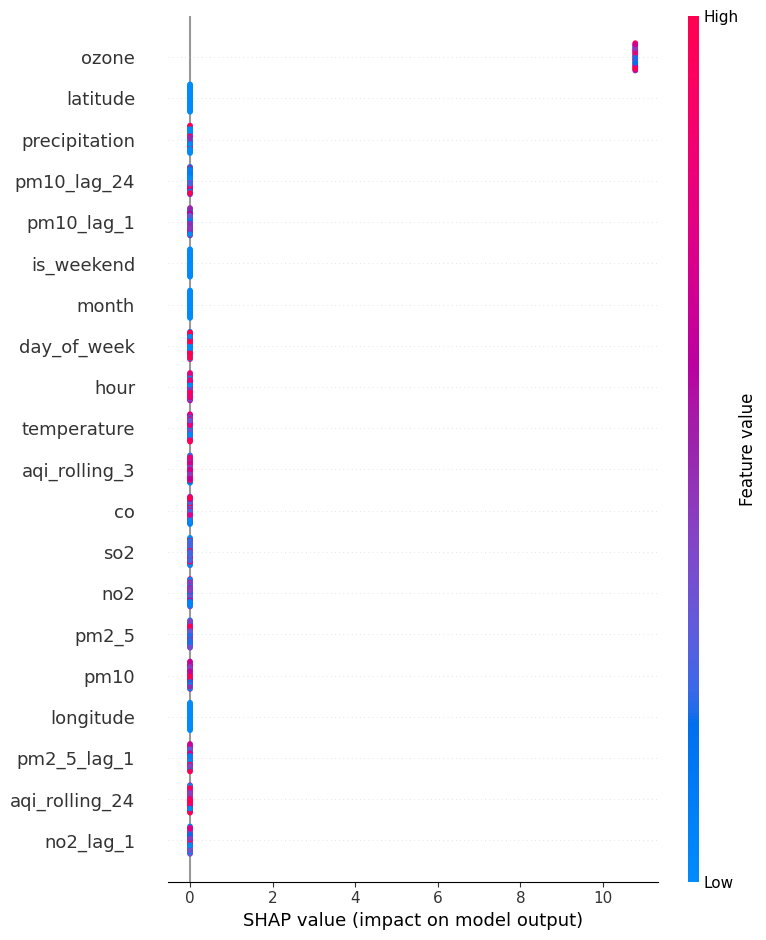

In [32]:
# Explicador 
explainer = shap.TreeExplainer(model)

# valores sin escalar (visualiza mejor)
X_test_df = X_test.copy()
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

El gráfico SHAP muestra que el modelo usa principalmente el ozono para hacer las predicciones. El resto de variables tienen menos impacto, probablemente porque están correlacionadas entre sí o porque el dataset no es muy grande.

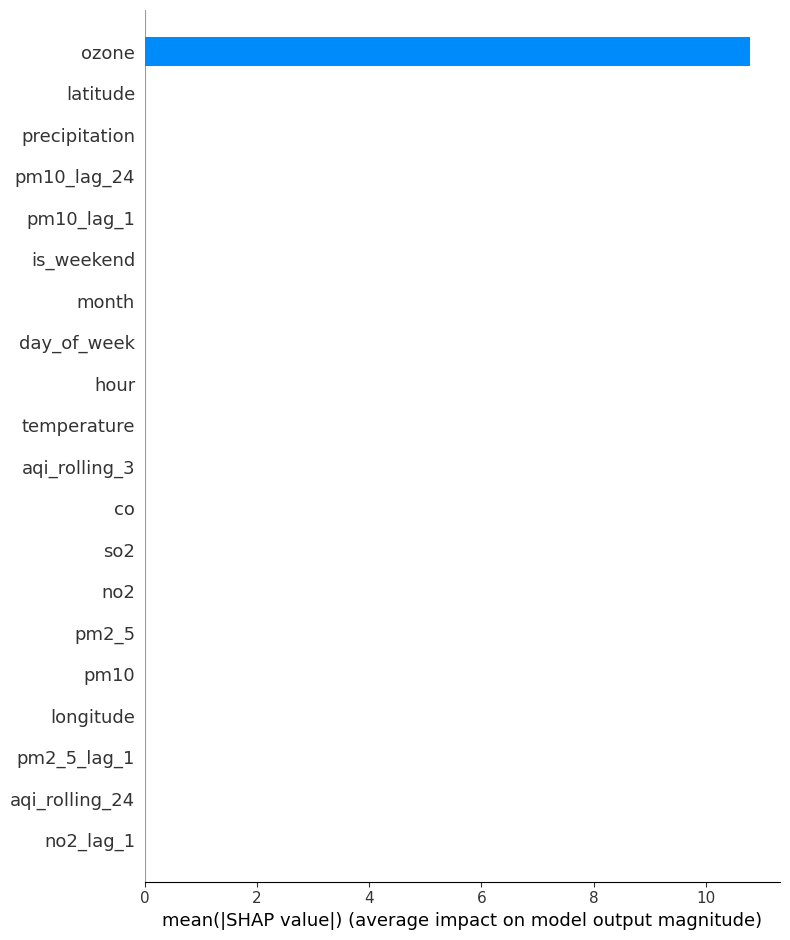

In [33]:
explainer = shap.TreeExplainer(model)

X_test_df = X_test.copy()
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test, plot_type="bar")

El gráfico SHAP muestra que el modelo utiliza principalmente el ozono para hacer las predicciones. Esto tiene sentido porque el AQI depende directamente de los contaminantes. El modelo simplifica y se queda con la variable más representativa.

# **Gráficos**

### ***Predicción vs Real***

40 40


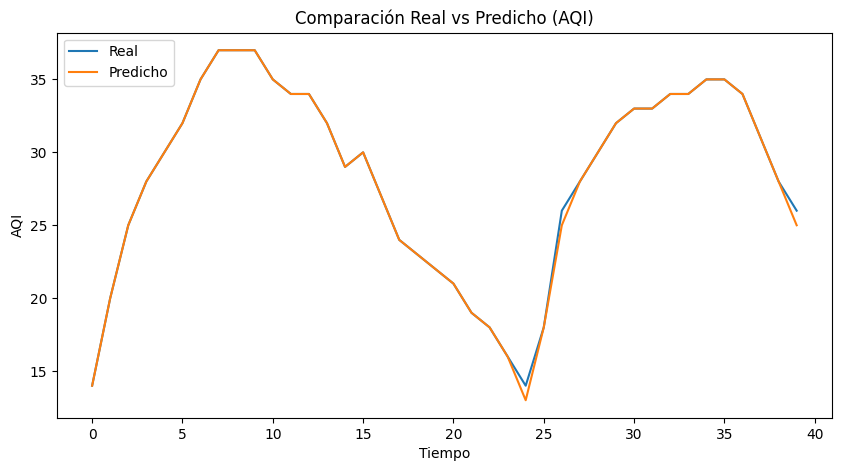

In [ ]:
y_pred = model.predict(X_test_scaled)

print(len(y_test), len(y_pred))

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Real")
plt.plot(y_pred[:100], label="Predicho")
plt.legend()
plt.title("Comparación Real vs Predicho (AQI)")
plt.xlabel("Tiempo")
plt.ylabel("AQI")
plt.show()

El modelo sigue muy bien la evolución del AQI, tanto en subidas como bajadas, lo que indica que ha aprendido correctamente los patrones temporales.

### ***Distribución del AQI***

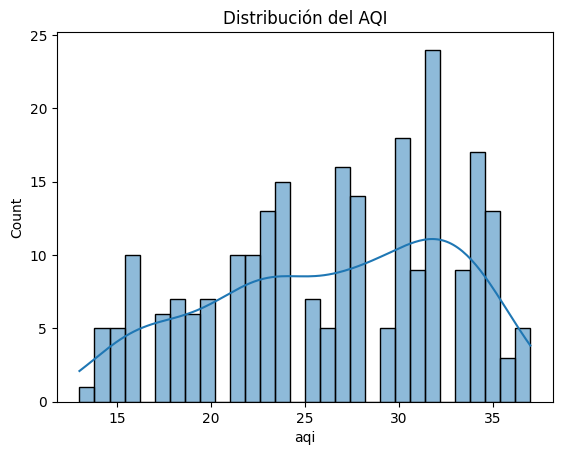

In [35]:
import seaborn as sns

sns.histplot(df["aqi"], bins=30, kde=True)
plt.title("Distribución del AQI")
plt.show()

La mayoría de los valores están en rangos medios, lo que hace que el modelo sea más estable y no tenga que enfrentarse a valores extremos difíciles de predecir.

### ***AQI en el tiempo***

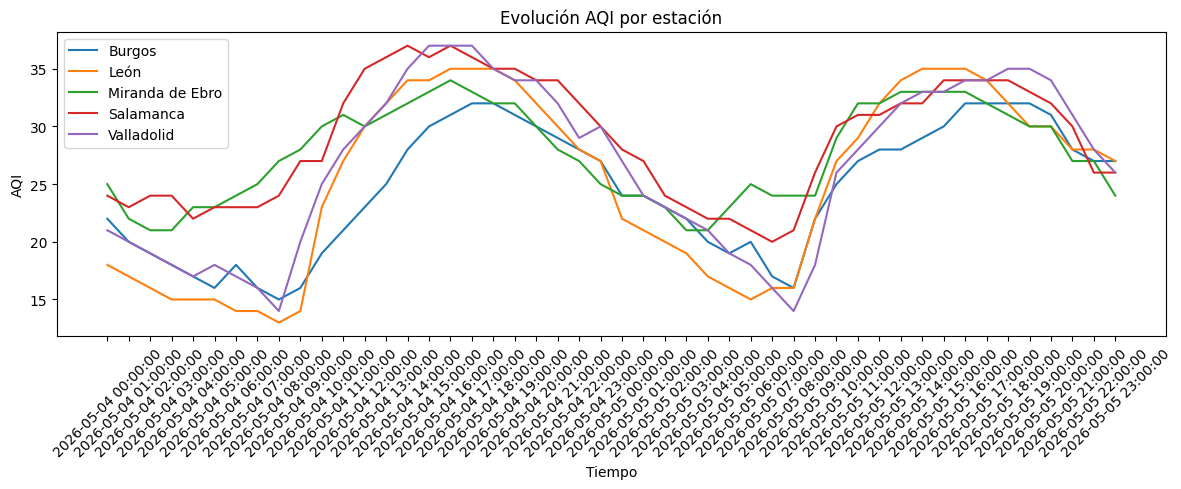

In [36]:
plt.figure(figsize=(12,5))

for station in df["station"].unique():
    df_plot = df[df["station"] == station]
    plt.plot(df_plot["time"], df_plot["aqi"], label=station)

plt.legend()
plt.xticks(rotation=45)
plt.title("Evolución AQI por estación")
plt.xlabel("Tiempo")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

Todas las ciudades siguen prácticamente el mismo patrón: baja por la noche, sube durante el día y vuelve a bajar. Esto tiene sentido porque el tráfico y la actividad aumentan durante el día. El hecho de que todas se comporten parecido indica que el modelo está captando bien la dinámica del problema.

### ***Real vs Predicho***

Tamaño y_test: 40
Tamaño y_pred: 40


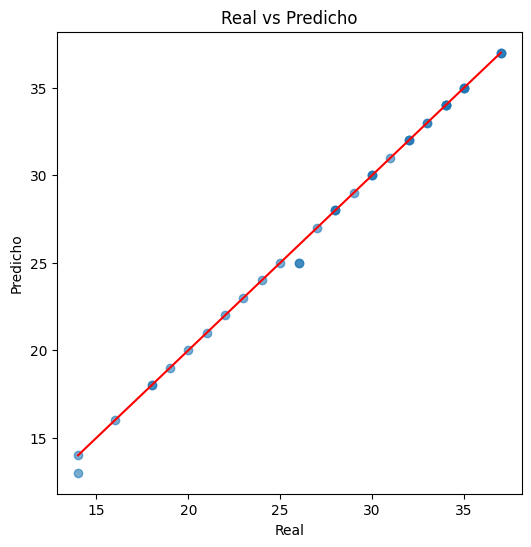

In [37]:
y_pred_actual = model.predict(X_test_scaled)

print("Tamaño y_test:", len(y_test))
print("Tamaño y_pred:", len(y_pred_actual))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_actual, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.show()

El gráfico de dispersión muestra una alineación cercana a la diagonal, lo que indica una alta concordancia entre valores reales y predichos, reflejando un buen rendimiento del modelo.

# **Optuna**

In [38]:
# !pip install optuna

In [39]:
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "objective": "reg:squarederror",
    }

    tscv = TimeSeriesSplit(n_splits=5)
    rmses = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = XGBRegressor(**params)
        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        rmses.append(rmse)

    return np.mean(rmses)

### ***Ejecutar búsqueda***

In [40]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Mejor RMSE:", study.best_value)
print("Mejores parámetros:")
print(study.best_params)

[I 2026-05-03 15:38:42,008] A new study created in memory with name: no-name-dba403c0-bc61-4354-8acd-2a05d8cfe93b
[I 2026-05-03 15:38:42,452] Trial 0 finished with value: 0.9990274678251317 and parameters: {'n_estimators': 505, 'max_depth': 3, 'learning_rate': 0.07279590785979224, 'subsample': 0.6520951607977145, 'colsample_bytree': 0.895091785477834, 'min_child_weight': 7}. Best is trial 0 with value: 0.9990274678251317.
[I 2026-05-03 15:38:42,656] Trial 1 finished with value: 1.125242529531624 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.15346595442648958, 'subsample': 0.7308365419375891, 'colsample_bytree': 0.6929289437780934, 'min_child_weight': 8}. Best is trial 0 with value: 0.9990274678251317.
[I 2026-05-03 15:38:42,961] Trial 2 finished with value: 0.6936435748970204 and parameters: {'n_estimators': 219, 'max_depth': 5, 'learning_rate': 0.19050146350780475, 'subsample': 0.8329266237563131, 'colsample_bytree': 0.9990383247767687, 'min_child_weight': 4

Mejor RMSE: 0.5222038551836
Mejores parámetros:
{'n_estimators': 359, 'max_depth': 3, 'learning_rate': 0.13024877753802377, 'subsample': 0.9565883519544374, 'colsample_bytree': 0.9538739379714439, 'min_child_weight': 1}


### ***Entrenar modelo final optimizado***

In [41]:
best_params = study.best_params

best_model = XGBRegressor(
    **best_params,
    random_state=42,
    objective="reg:squarederror"
)

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model.fit(X_train_scaled, y_train)

y_pred_optuna = best_model.predict(X_test_scaled)

### ***Evaluación***

In [42]:
mae = mean_absolute_error(y_test, y_pred_optuna)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
r2 = r2_score(y_test, y_pred_optuna)

print("MAE Optuna:", mae)
print("RMSE Optuna:", rmse)
print("R2 Optuna:", r2)

MAE Optuna: 0.12363479534784953
RMSE Optuna: 0.301016981422197
R2 Optuna: 0.998223066329956


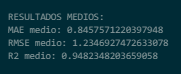

Hemos usado Optuna para optimizar automáticamente los parámetros del modelo. Esto ha mejorado bastante el rendimiento, reduciendo el error. Aunque el R2 es muy alto, lo validamos con TimeSeriesSplit para asegurarnos de que no es overfitting.

# **APP**

In [43]:
# ! pip install streamlit folium streamlit-folium

In [ ]:
# ! pip install fastapi uvicorn joblib

: 

In [ ]:
# ! pip install pytest httpx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pytest]2m2/3 [pytest]


# **Predicción Futura**

### ***Target futuro***

In [44]:
from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

df = pd.read_csv(BASE_DIR / "data" / "processed" / "air_weather_features.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["station", "time"]).reset_index(drop=True)

HORIZON = 1
df["aqi_future"] = df.groupby("station")["aqi"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

### ***Entrenamiento futuro***

In [45]:
target = "aqi_future"

features = [
    col for col in df.columns
    if col not in ["time", "station", "aqi_future"]
]

X = df[features]
y = df[target]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

future_model = XGBRegressor(
    n_estimators=588,
    max_depth=10,
    learning_rate=0.15711609754694855,
    subsample=0.9665294698777079,
    colsample_bytree=0.8401,
    random_state=42,
    objective="reg:squarederror"
)

future_model.fit(X_train_scaled, y_train)

y_pred_future = future_model.predict(X_test_scaled)

print("MAE futuro:", mean_absolute_error(y_test, y_pred_future))
print("RMSE futuro:", np.sqrt(mean_squared_error(y_test, y_pred_future)))
print("R2 futuro:", r2_score(y_test, y_pred_future))

MAE futuro: 1.208195483430903
RMSE futuro: 1.7974367545396097
R2 futuro: 0.9371451546498901


### ***Modelo guardado***

In [46]:
import joblib

MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(future_model, MODELS_DIR / "xgb_future_model.pkl")
joblib.dump(scaler, MODELS_DIR / "future_scaler.pkl")
joblib.dump(features, MODELS_DIR / "future_features.pkl")

print("Modelo futuro guardado correctamente.")

Modelo futuro guardado correctamente.


### ***Streamlit***

 streamlit run app/streamlit/app.py --server.port 8503 --server.address 0.0.0.0

### ***Fast API***
uvicorn app.api.main:app --host 0.0.0.0 --port 8000 --reload

http://localhost:8000/docs

{
  "station": "Burgos"
}

### ***Test de integración de la API***

PYTHONPATH=. pytest tests/test_api_integration.py